# 03 — Model Training & Evaluation
**Indoor WiFi Fingerprinting Localization**

We have 317 train / 69 val / 69 test samples, 116 BSSID features, 19 locations.
Dataset is small and balanced (~17 samples/class in train).

### Models compared
| Model | Features | Notes |
|-------|----------|-------|
| kNN   | scaled   | Classic fingerprinting baseline |
| Random Forest | raw | Handles sparsity well, no scaling needed |
| SVM (RBF) | scaled | Strong on small datasets |
| Gradient Boosting | raw | Often best on tabular data |

### Strategy
1. Grid-search each model on **train + val** (combined) with 5-fold CV
2. Pick best hyperparams per model
3. Final train on **train + val**, evaluate on held-out **test**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

In [18]:
ROOT      = Path('../../')
SPLITS    = ROOT / 'Data' / '02_Processed_Wifi_Daytime' / 'splits'
MODELS    = ROOT / 'Data' / '02_Processed_Wifi_Daytime' / 'models'
MODELS.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 69

## 1. Load splits

In [19]:
X_train     = np.load(SPLITS / 'train_X.npy')
X_train_sc  = np.load(SPLITS / 'train_X_scaled.npy')
y_train     = np.load(SPLITS / 'train_y.npy')

X_val       = np.load(SPLITS / 'val_X.npy')
X_val_sc    = np.load(SPLITS / 'val_X_scaled.npy')
y_val       = np.load(SPLITS / 'val_y.npy')

X_test      = np.load(SPLITS / 'test_X.npy')
X_test_sc   = np.load(SPLITS / 'test_X_scaled.npy')
y_test      = np.load(SPLITS / 'test_y.npy')

label_map   = json.load(open(SPLITS / 'label_map.json'))
class_names = [label_map[str(i)] for i in range(len(label_map))]

# Combine train+val for final training (after CV selects best params)
X_trainval    = np.vstack([X_train,    X_val])
X_trainval_sc = np.vstack([X_train_sc, X_val_sc])
y_trainval    = np.concatenate([y_train, y_val])

print(f'Train    : {X_train.shape}')
print(f'Val      : {X_val.shape}')
print(f'Test     : {X_test.shape}')
print(f'TrainVal : {X_trainval.shape}')
print(f'Classes  : {len(class_names)}')

Train    : (317, 116)
Val      : (69, 116)
Test     : (69, 116)
TrainVal : (386, 116)
Classes  : 19


## 2. Helper utilities

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

results = {}   # model_name → {val_acc, test_acc, model}

def evaluate(name, model, X_tr, y_tr, X_te, y_te, X_tv, y_tv):
    """Grid-search on train, report val acc; retrain on trainval, report test acc."""
    val_pred  = model.predict(X_te)           # X_te here = val set during tuning
    val_acc   = accuracy_score(y_te, val_pred)

    # retrain on full trainval, evaluate on held-out test
    model.fit(X_tv, y_tv)
    test_pred = model.predict(X_test_sc if 'knn' in name.lower() or 'svm' in name.lower()
                              else X_test)
    test_acc  = accuracy_score(y_test, test_pred)

    results[name] = {'val_acc': val_acc, 'test_acc': test_acc,
                     'model': model, 'test_pred': test_pred}
    print(f'{name:<25}  val: {val_acc:.3f}   test: {test_acc:.3f}')
    return model


## 3. kNN
Classic WiFi fingerprinting algorithm. Uses Euclidean distance on normalized RSSI vectors.

In [21]:
knn_params = {
    'n_neighbors': [1, 2, 3, 5, 7, 10],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan'],
}
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
knn_gs.fit(X_train_sc, y_train)
print('Best kNN params:', knn_gs.best_params_)
print(f'CV accuracy    : {knn_gs.best_score_:.3f}')

best_knn = knn_gs.best_estimator_
val_pred = best_knn.predict(X_val_sc)
val_acc  = accuracy_score(y_val, val_pred)

best_knn.fit(X_trainval_sc, y_trainval)
test_pred_knn = best_knn.predict(X_test_sc)
test_acc_knn  = accuracy_score(y_test, test_pred_knn)

results['kNN'] = {'val_acc': val_acc, 'test_acc': test_acc_knn,
                  'model': best_knn, 'test_pred': test_pred_knn}
print(f'\nkNN  →  val: {val_acc:.3f}   test: {test_acc_knn:.3f}')

Best kNN params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
CV accuracy    : 0.830

kNN  →  val: 0.841   test: 0.855


## 4. Random Forest
Handles sparse RSSI features naturally. Raw (unscaled) features work fine.

In [22]:
rf_params = {
    'n_estimators'    : [100, 300, 500],
    'max_features'    : ['sqrt', 'log2', 0.3],
    'min_samples_leaf': [1, 2, 3],
}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    rf_params,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train, y_train)
print('Best RF params:', rf_gs.best_params_)
print(f'CV accuracy   : {rf_gs.best_score_:.3f}')

best_rf = rf_gs.best_estimator_
val_pred = best_rf.predict(X_val)
val_acc  = accuracy_score(y_val, val_pred)

best_rf.fit(X_trainval, y_trainval)
test_pred_rf = best_rf.predict(X_test)
test_acc_rf  = accuracy_score(y_test, test_pred_rf)

results['Random Forest'] = {'val_acc': val_acc, 'test_acc': test_acc_rf,
                             'model': best_rf, 'test_pred': test_pred_rf}
print(f'\nRF   →  val: {val_acc:.3f}   test: {test_acc_rf:.3f}')

Best RF params: {'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}
CV accuracy   : 0.947

RF   →  val: 0.957   test: 0.942


## 5. SVM (RBF kernel)
Excellent on small, high-dimensional datasets. Uses scaled features.

In [23]:
svm_params = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
}
svm_gs = GridSearchCV(
    SVC(kernel='rbf', random_state=RANDOM_SEED),
    svm_params,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
svm_gs.fit(X_train_sc, y_train)
print('Best SVM params:', svm_gs.best_params_)
print(f'CV accuracy    : {svm_gs.best_score_:.3f}')

best_svm = svm_gs.best_estimator_
val_pred = best_svm.predict(X_val_sc)
val_acc  = accuracy_score(y_val, val_pred)

best_svm.fit(X_trainval_sc, y_trainval)
test_pred_svm = best_svm.predict(X_test_sc)
test_acc_svm  = accuracy_score(y_test, test_pred_svm)

results['SVM'] = {'val_acc': val_acc, 'test_acc': test_acc_svm,
                  'model': best_svm, 'test_pred': test_pred_svm}
print(f'\nSVM  →  val: {val_acc:.3f}   test: {test_acc_svm:.3f}')

Best SVM params: {'C': 100, 'gamma': 0.001}
CV accuracy    : 0.830

SVM  →  val: 0.797   test: 0.884


## 6. Gradient Boosting
Strong tabular model. Raw features, sequential ensemble.

In [24]:
gb_params = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0],
}
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_SEED),
    gb_params,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
gb_gs.fit(X_train, y_train)
print('Best GB params:', gb_gs.best_params_)
print(f'CV accuracy   : {gb_gs.best_score_:.3f}')

best_gb = gb_gs.best_estimator_
val_pred = best_gb.predict(X_val)
val_acc  = accuracy_score(y_val, val_pred)

best_gb.fit(X_trainval, y_trainval)
test_pred_gb = best_gb.predict(X_test)
test_acc_gb  = accuracy_score(y_test, test_pred_gb)

results['Gradient Boosting'] = {'val_acc': val_acc, 'test_acc': test_acc_gb,
                                 'model': best_gb, 'test_pred': test_pred_gb}
print(f'\nGB   →  val: {val_acc:.3f}   test: {test_acc_gb:.3f}')

Best GB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
CV accuracy   : 0.887

GB   →  val: 0.870   test: 0.884


## 7. Comparison summary

In [25]:
summary = pd.DataFrame({
    name: {'Val Acc': v['val_acc'], 'Test Acc': v['test_acc']}
    for name, v in results.items()
}).T.sort_values('Test Acc', ascending=False)

summary['Val Acc']  = summary['Val Acc'].map('{:.1%}'.format)
summary['Test Acc'] = summary['Test Acc'].map('{:.1%}'.format)
print(summary.to_string())

best_model_name = max(results, key=lambda k: results[k]['test_acc'])
print(f'\nBest model: {best_model_name}  (test acc: {results[best_model_name]["test_acc"]:.1%})')

                  Val Acc Test Acc
Random Forest       95.7%    94.2%
SVM                 79.7%    88.4%
Gradient Boosting   87.0%    88.4%
kNN                 84.1%    85.5%

Best model: Random Forest  (test acc: 94.2%)


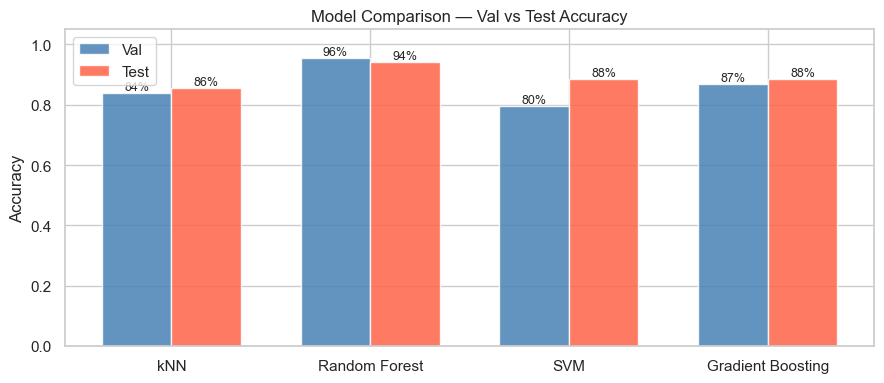

In [26]:
# Bar chart comparison
names = list(results.keys())
val_accs  = [results[n]['val_acc']  for n in names]
test_accs = [results[n]['test_acc'] for n in names]

x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, val_accs,  w, label='Val',  color='steelblue', alpha=0.85)
ax.bar(x + w/2, test_accs, w, label='Test', color='tomato',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Val vs Test Accuracy')
ax.legend()
for i, (v, t) in enumerate(zip(val_accs, test_accs)):
    ax.text(i - w/2, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)
    ax.text(i + w/2, t + 0.01, f'{t:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(MODELS / 'model_comparison.png', dpi=100)
plt.show()

## 8. Best model — detailed evaluation on test set

In [27]:
best = results[best_model_name]
y_pred = best['test_pred']

print(f'=== {best_model_name} — Test Set Report ===')
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

=== Random Forest — Test Set Report ===
                                         precision    recall  f1-score   support

       Btw_DLT_8_and_F_Chamber_Entrance      1.000     1.000     1.000         3
                    Btw_Stairs_and_DLT7      1.000     1.000     1.000         3
                D-151/1 Computation Lab      1.000     1.000     1.000         4
                        D-151/2_D-153/1      1.000     1.000     1.000         3
                                  D-152      1.000     1.000     1.000         4
                    D-153/2 SMART Space      1.000     0.667     0.800         3
                                  D-154      0.750     1.000     0.857         3
                      D-157,158,159,160      0.800     1.000     0.889         4
                      D-161,162,163,164      1.000     0.750     0.857         4
                      D-165,166,167,168      0.750     1.000     0.857         3
                            D-169, CAIR      1.000     0.750     0.8

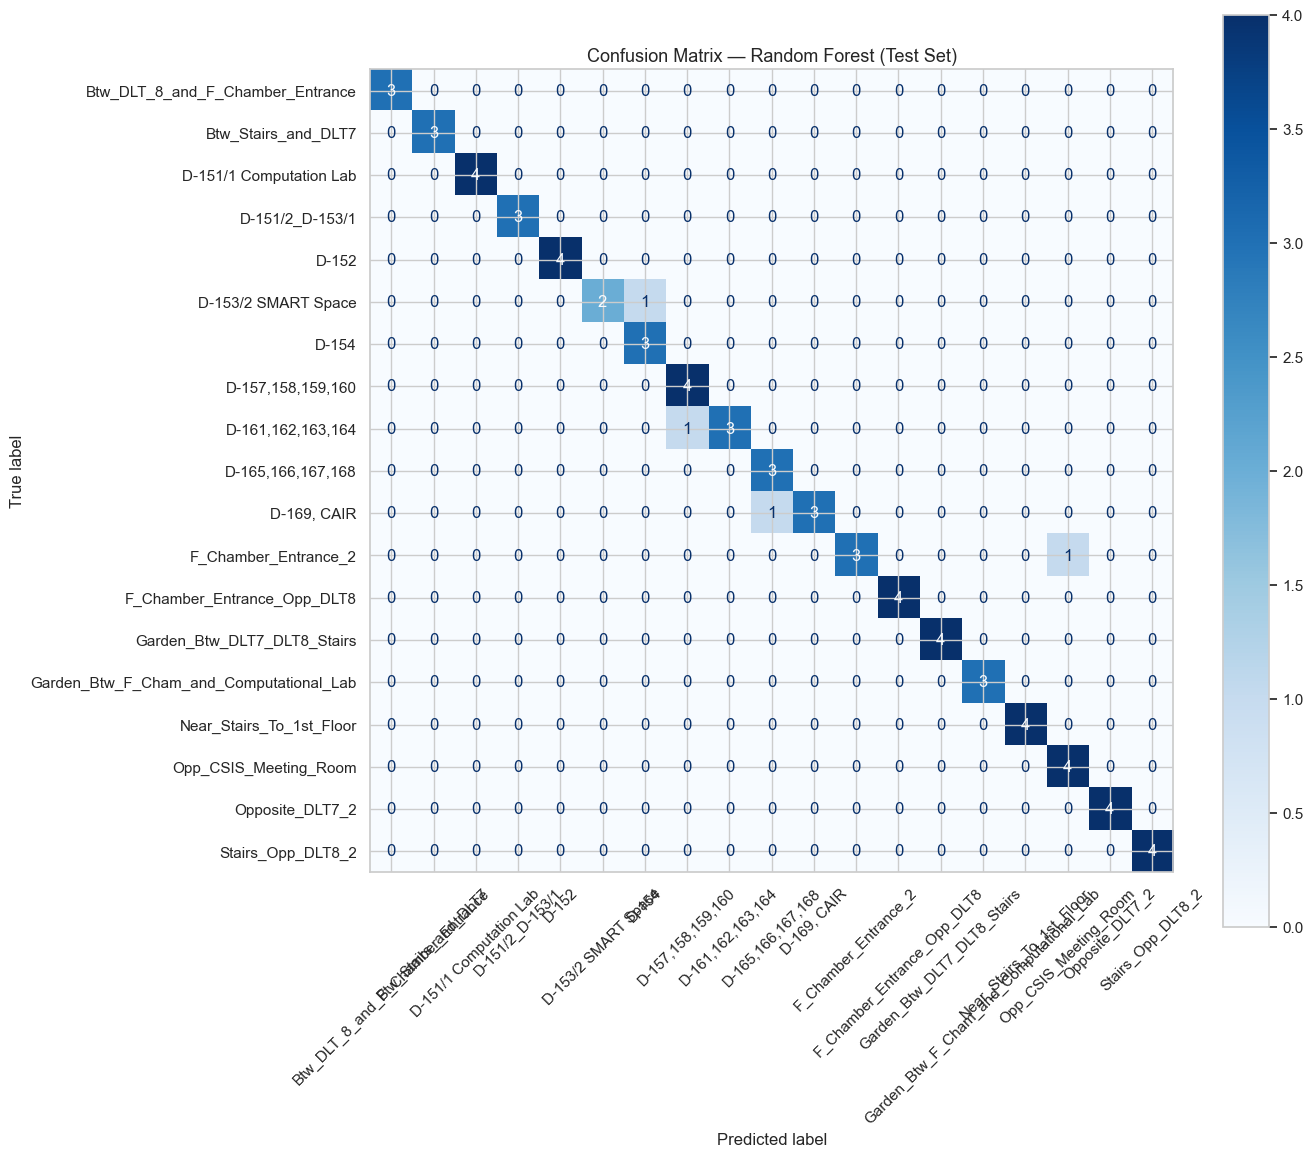

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — {best_model_name} (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS / f'confusion_{best_model_name.lower().replace(" ","_")}.png', dpi=100)
plt.show()

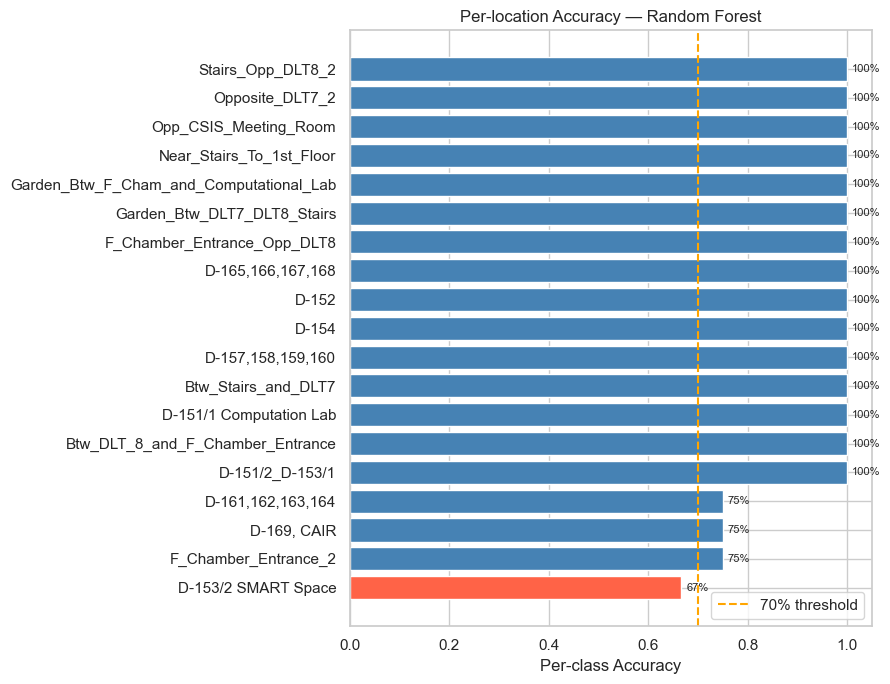

In [29]:
# Per-class accuracy
per_class = cm.diagonal() / cm.sum(axis=1)
pc_df = pd.DataFrame({'Location': class_names, 'Accuracy': per_class})\
          .sort_values('Accuracy')

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['tomato' if v < 0.7 else 'steelblue' for v in pc_df['Accuracy']]
ax.barh(pc_df['Location'], pc_df['Accuracy'], color=colors)
ax.axvline(0.7, color='orange', linestyle='--', label='70% threshold')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Per-class Accuracy')
ax.set_title(f'Per-location Accuracy — {best_model_name}')
ax.legend()
for i, (loc, acc) in enumerate(zip(pc_df['Location'], pc_df['Accuracy'])):
    ax.text(acc + 0.01, i, f'{acc:.0%}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(MODELS / 'per_class_accuracy.png', dpi=100)
plt.show()

## 9. Feature importance (tree models)

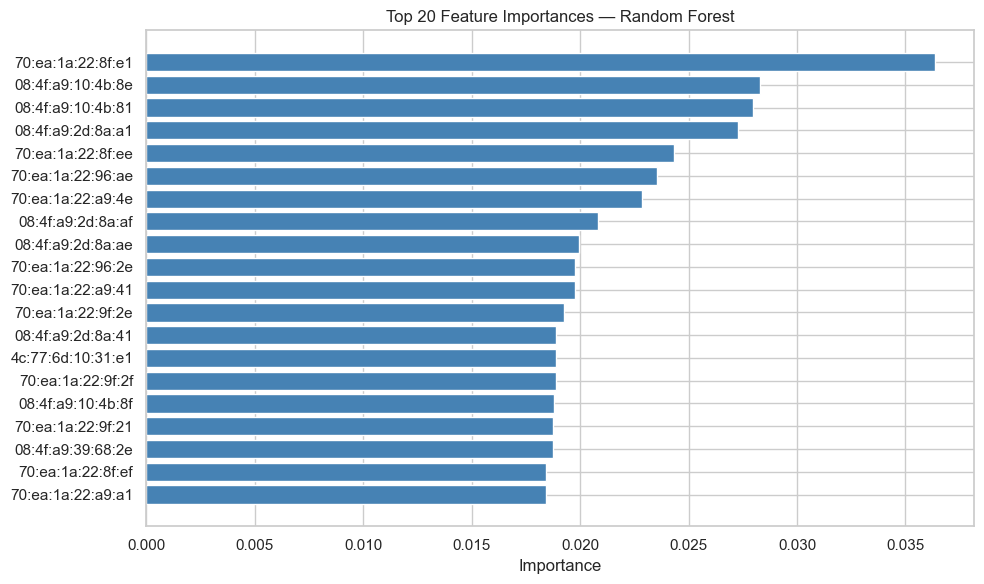

In [30]:
import json
feature_bssids = json.load(open(SPLITS / 'feature_bssids.json'))

tree_model_name = None
for name in ['Random Forest', 'Gradient Boosting']:
    if name in results:
        tree_model_name = name
        break

if tree_model_name:
    importances = results[tree_model_name]['model'].feature_importances_
    fi = pd.DataFrame({'BSSID': feature_bssids, 'Importance': importances})\
           .sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi['BSSID'], fi['Importance'], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Feature Importances — {tree_model_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(MODELS / 'feature_importance.png', dpi=100)
    plt.show()
else:
    print('No tree model trained.')

## 10. Save all models
Each model is saved as its own bundle — the app can load any of them by name.

Every bundle has the same interface:
- `model` — trained classifier
- `scaler` — StandardScaler if the model needs it, else `None`
- `feature_bssids` — ordered BSSID list (must match scan columns)
- `label_map` — `{int: location_name}`
- `needs_scaling`, `model_name`, `test_accuracy`, `rssi_missing`

A `models_registry.json` is also saved so the app can enumerate what's available.

In [31]:
scaler_obj = joblib.load(SPLITS / 'scaler.joblib')

NEEDS_SCALING = {'kNN', 'SVM'}
registry = {}

for model_name, res in results.items():
    needs_scaling = model_name in NEEDS_SCALING
    safe_name = model_name.replace(' ', '_')   # e.g. "Random Forest" → "Random_Forest"

    bundle = {
        'model'         : res['model'],
        'scaler'        : scaler_obj if needs_scaling else None,
        'feature_bssids': feature_bssids,
        'label_map'     : label_map,
        'needs_scaling' : needs_scaling,
        'model_name'    : model_name,
        'test_accuracy' : res['test_acc'],
        'n_features'    : len(feature_bssids),
        'n_classes'     : len(label_map),
        'rssi_missing'  : -100,
    }
    out = MODELS / f'{safe_name}.joblib'
    joblib.dump(bundle, out)
    registry[model_name] = {
        'file'         : f'{safe_name}.joblib',
        'test_accuracy': round(res['test_acc'], 4),
        'val_accuracy' : round(res['val_acc'],  4),
        'needs_scaling': needs_scaling,
    }
    print(f'  Saved {out.name}  (test: {res["test_acc"]:.1%})')

# Registry file — app reads this to know which models exist
with open(MODELS / 'models_registry.json', 'w') as f:
    json.dump(registry, f, indent=2)

print(f'\nRegistry saved: {(MODELS / "models_registry.json").resolve()}')
print('\nAll models:')
for name, info in sorted(registry.items(), key=lambda x: -x[1]['test_accuracy']):
    print(f'  {name:<25} test={info["test_accuracy"]:.1%}  file={info["file"]}')

  Saved kNN.joblib  (test: 85.5%)
  Saved Random_Forest.joblib  (test: 94.2%)
  Saved SVM.joblib  (test: 88.4%)
  Saved Gradient_Boosting.joblib  (test: 88.4%)

Registry saved: D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\02_Processed_Wifi_Daytime\models\models_registry.json

All models:
  Random Forest             test=94.2%  file=Random_Forest.joblib
  SVM                       test=88.4%  file=SVM.joblib
  Gradient Boosting         test=88.4%  file=Gradient_Boosting.joblib
  kNN                       test=85.5%  file=kNN.joblib


## 11. Inference demo
Shows how to use the bundle to predict a location from a raw WiFi scan dictionary.

In [32]:
def predict_location(scan_dict: dict, bundle: dict) -> str:
    """
    Predict location from a single WiFi scan.

    Parameters
    ----------
    scan_dict : {bssid: rssi, ...}  — dict of observed BSSIDs and their RSSI
    bundle    : loaded joblib bundle (any model)

    Returns
    -------
    str — predicted location name
    """
    rssi_missing = bundle['rssi_missing']
    x = np.array([scan_dict.get(bssid, rssi_missing)
                  for bssid in bundle['feature_bssids']], dtype=np.float32).reshape(1, -1)
    if bundle['needs_scaling']:
        x = bundle['scaler'].transform(x)
    pred_idx = bundle['model'].predict(x)[0]
    return bundle['label_map'][str(pred_idx)]


# ── Demo: load any model by name and run inference ───────────────────────────
registry = json.load(open(MODELS / 'models_registry.json'))

for model_name, info in sorted(registry.items(), key=lambda x: -x[1]['test_accuracy']):
    bundle = joblib.load(MODELS / info['file'])

    # Use first test sample as a mock phone scan (only pass observed APs)
    sample_dict = {bssid: float(rssi)
                   for bssid, rssi in zip(feature_bssids, X_test[0])
                   if rssi > -100}

    predicted = predict_location(sample_dict, bundle)
    actual    = label_map[str(y_test[0])]
    correct   = '✓' if predicted == actual else '✗'
    print(f'{correct}  {model_name:<25}  pred={predicted}  actual={actual}')

✓  Random Forest              pred=Btw_Stairs_and_DLT7  actual=Btw_Stairs_and_DLT7
✗  SVM                        pred=Near_Stairs_To_1st_Floor  actual=Btw_Stairs_and_DLT7
✓  Gradient Boosting          pred=Btw_Stairs_and_DLT7  actual=Btw_Stairs_and_DLT7
✓  kNN                        pred=Btw_Stairs_and_DLT7  actual=Btw_Stairs_and_DLT7
